# 05 — `renfe_cercanias`: posiciones y retrasos de Cercanías

**Origen.** `flota.json` de Renfe, filtrado por `nucleo == "40"` (València).
Sondeo cada 30 s.

**Papel en el TFM.** Doble, y ninguno es el central:

1. **Covariable de contexto**: una incidencia ferroviaria vuelca viajeros al bus.
2. **Referencia metodológica**, que es lo interesante: Renfe **publica el retraso
   ya calculado** (`retraso_min`). Es la única fuente del corpus donde se ve cómo
   se comporta un retraso de transporte público real, y sirve para calibrar
   expectativas sobre la variable que el TFM va a construir para la EMT.

**Trampa que aplica:**

| id | qué |
|----|-----|
| [003](../../.claude/trampas/003-raiz-renfe-es-objeto.md) | La raíz del JSON es un objeto, no un array. Sin filtrar `nucleo == "40"` te llevas la flota nacional sin que salte ningún error |

In [1]:
import sys
from pathlib import Path

# El notebook debe correr tanto abierto desde notebooks/EDA como ejecutado
# desde la raíz del repo (nbclient, CI).
AQUI = Path("notebooks/EDA").resolve() if Path("notebooks/EDA").exists() else Path.cwd()
sys.path.insert(0, str(AQUI))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import eda_utils as eu

eu.estilo()
FUENTE = "renfe_cercanias"
print("corpus:", eu.dir_fuente(FUENTE))

corpus: C:\Users\oppen\Code\TFM\data\curated\source=renfe_cercanias


## 1. Censo y esquema

In [2]:
eu.censo(FUENTE)

,valor
métrica,
fuente,renfe_cercanias
filas,"456,312"
ficheros parquet,530
particiones (días),17
tamaño en disco,11.9 MB
ts_utc mínimo,2026-08-15 20:14:37+00:00
ts_utc máximo,2026-08-31 16:33:35+00:00


In [3]:
eu.esquema(FUENTE)

,columna,tipo
0,tripId,VARCHAR
1,codTren,VARCHAR
2,codLinea,VARCHAR
3,retraso_min,BIGINT
4,codEstAct,VARCHAR
5,codEstSig,VARCHAR
6,eta_sig_est_utc,TIMESTAMP WITH TIME ZONE
7,codEstOrig,VARCHAR
8,codEstDest,VARCHAR
9,porAvanc,VARCHAR


## 2. Calidad

In [4]:
eu.perfil_nulos(FUENTE)

,columna,nulos,pct_nulos,distintos,constante
9,porAvanc,45829,10.043,103,False
0,tripId,0,0.000,3494,False
1,codTren,0,0.000,284,False
3,retraso_min,0,0.000,177,False
2,codLinea,0,0.000,5,False
5,codEstSig,0,0.000,54,False
6,eta_sig_est_utc,0,0.000,79926,False
7,codEstOrig,0,0.000,15,False
4,codEstAct,0,0.000,53,False
8,codEstDest,0,0.000,13,False


In [5]:
eu.duplicados(FUENTE, ["ts_ingest_utc", "tripId"])

,filas,combinaciones_unicas,duplicadas
0,456312,456312,0


## 3. Trampa 003 — que solo haya entrado el núcleo 40

El filtro se aplica en ingesta y no deja rastro en la tabla, así que se verifica
por sus consecuencias: si se hubiera colado la flota nacional, la caja envolvente
se saldría de la Comunitat Valenciana y aparecerían códigos de línea ajenos.

In [6]:
eu.bbox(FUENTE)

,con_posicion,lat_min,lat_max,lon_min,lon_max,sin_posicion
0,456312,38.878,40.472,-1.202,0.456,0.000


In [7]:
eu.frecuencias(FUENTE, "codLinea")

,valor,filas,pct,pct_acum
0,C2,141843,31.085,31.085
1,C1,125049,27.404,58.489
2,C6,122478,26.841,85.330
3,C3,62344,13.663,98.992
4,C5,4598,1.008,100.000


Cinco códigos `C-x` y una caja envolvente que no se sale de la Comunitat: el
filtro está haciendo su trabajo. Es la comprobación que hay que repetir cada vez
que se toque `ingest/sources.py`, porque el fallo no lanza excepción — solo
multiplica las filas por veinte.

Ahora bien, **esa caja es enorme comparada con la de los buses**: llega de Utiel
(oeste, línea C3) hasta el norte de Castelló, más de 150 km de extremo a extremo,
frente a los ~20 km de la flota de la EMT. El núcleo 40 es una red regional, no
urbana. Como covariable de contexto para un autobús de València, lo que tiene
sentido no es la posición de un tren cualquiera sino **el estado agregado de la
red en la franja**, o como mucho el de los trenes que entran y salen de la ciudad.

## 4. `retraso_min`: cómo se ve un retraso publicado

In [8]:
eu.resumen_numerico(FUENTE, ["retraso_min"]).round(2)

,n,media,mediana,moda,desv,min,p01,p25,p75,p99,max,iqr,atipicos_iqr,pct_atipicos
columna,,,,,,,,,,,,,,
retraso_min,456312,1.870,0.000,0.000,5.600,"-1,271.000",-4.000,0.000,2.000,21.000,425.000,2.000,61755,13.530


retraso 0: 41.1 % | >5 min: 12.3 % | >15 min: 2.01 %


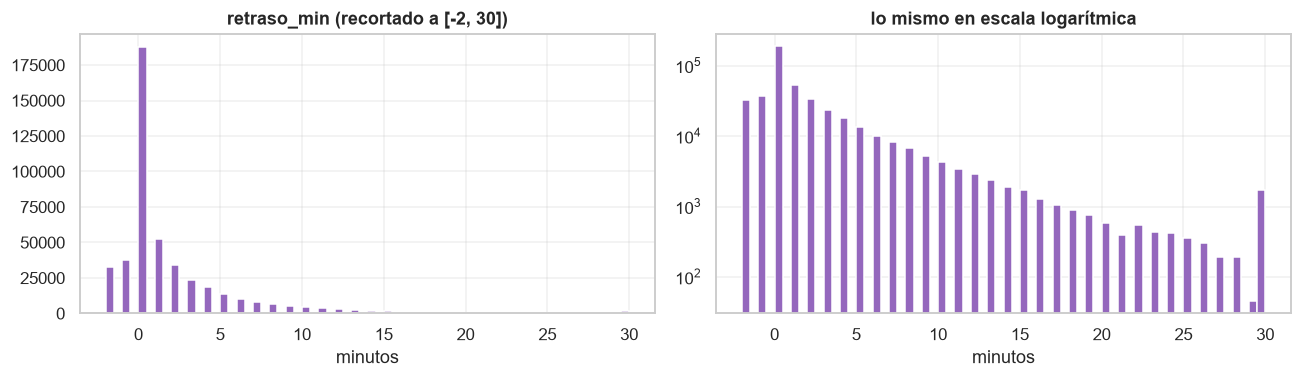

In [9]:
r = eu.sql("SELECT retraso_min FROM {f} WHERE retraso_min IS NOT NULL", f=FUENTE)["retraso_min"]
print(f"retraso 0: {100 * (r == 0).mean():.1f} % | >5 min: {100 * (r > 5).mean():.1f} % | >15 min: {100 * (r > 15).mean():.2f} %")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.6))
a1.hist(r.clip(-2, 30), bins=64, color=eu.PALETA[FUENTE])
a1.set_title("retraso_min (recortado a [-2, 30])")
a1.set_xlabel("minutos")
a2.hist(r.clip(-2, 30), bins=64, color=eu.PALETA[FUENTE], log=True)
a2.set_title("lo mismo en escala logarítmica")
a2.set_xlabel("minutos")
plt.tight_layout()
plt.show()

**Esta forma es la lección del notebook.** El retraso publicado es una
distribución con una masa enorme en cero y una cola larga a la derecha. Tres
consecuencias directas para la variable objetivo del TFM:

- el error absoluto medio va a estar dominado por los ceros, así que un modelo que
  prediga siempre "sin retraso" parecerá decente — de ahí que el **baseline de
  horario teórico (retraso = 0) sea obligatorio** antes de presumir de nada;
- la variante binaria `retraso > 5 min` va a estar **fuertemente desbalanceada**, y
  hay que reportar precisión/exhaustividad, no exactitud;
- hay valores extremos de cientos de minutos. Son incidencias reales, no errores,
  y decidir si se recortan es una decisión metodológica que debe quedar escrita.

In [10]:
# El máximo es enorme: ¿cola real o valor centinela?
eu.sql(
    """
    SELECT retraso_min, count(*) AS filas, count(DISTINCT tripId) AS viajes
    FROM {f} WHERE retraso_min > 60 GROUP BY 1 ORDER BY 1 DESC LIMIT 12
    """,
    f=FUENTE,
)

,retraso_min,filas,viajes
0,425,1,1
1,300,1,1
2,296,1,1
3,276,1,1
4,230,1,1
5,212,1,1
6,211,1,1
7,200,1,1
8,197,1,1
9,195,1,1


In [11]:
# El mínimo es de varias horas EN NEGATIVO. Un tren no puede adelantarse un día.
neg = eu.sql(
    """
    SELECT count(*) AS filas,
           sum(CASE WHEN retraso_min < 0 THEN 1 ELSE 0 END) AS negativos,
           sum(CASE WHEN retraso_min < -30 THEN 1 ELSE 0 END) AS menores_30min,
           min(retraso_min) AS minimo
    FROM {f}
    """,
    f=FUENTE,
)
print(neg.to_string(index=False))
eu.sql(
    """
    SELECT retraso_min, count(*) AS filas, count(DISTINCT tripId) AS viajes,
           any_value(codLinea) AS linea
    FROM {f} WHERE retraso_min < -30 GROUP BY 1 ORDER BY 1 LIMIT 12
    """,
    f=FUENTE,
)

 filas  negativos  menores_30min  minimo
456312 70,117.000         20.000   -1271


,retraso_min,filas,viajes,linea
0,-1271,1,1,C2
1,-230,1,1,C2
2,-227,1,1,C3
3,-145,1,1,C6
4,-133,1,1,C2
5,-109,1,1,C1
6,-73,1,1,C1
7,-62,1,1,C3
8,-54,1,1,C2
9,-47,2,2,C2


Hay que separar dos cosas que la palabra "negativo" junta:

- **la mayoría de los negativos son legítimos**: son trenes que van por delante del
  horario, de uno a pocos minutos. Un retraso negativo pequeño es información
  válida, y truncarlo a cero destruiría media distribución;
- **un puñado son imposibles**: llegan a las veintiuna horas de adelanto. Son
  artefactos del cruce de medianoche —el retraso calculado contra el horario del
  día equivocado— y se cuentan con los dedos sobre casi medio millón de filas.

El segundo grupo importa mucho más de lo que sugiere su tamaño, y no por esta
fuente: es la **advertencia para la etiqueta del TFM**. Cuando `prepare.py` calcule
el retraso del bus restando horario teórico y paso real, el cambio de día va a
producir exactamente este artefacto, con esta misma magnitud y esta misma
frecuencia baja — es decir, **sin dar la cara**. Aquí se ve ya cómo se manifiesta,
en una fuente donde el cálculo lo hizo otro.

## 5. Perfil temporal del retraso

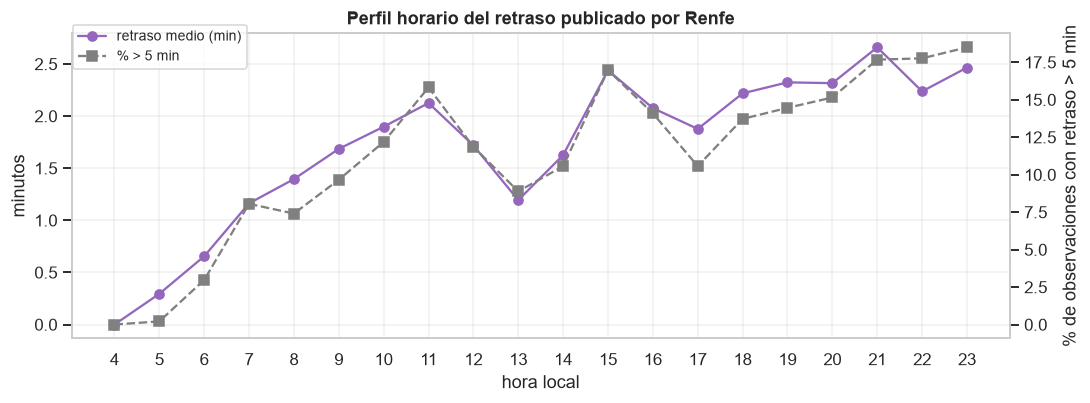

,hora_local,media,mediana,pct_mas_5min,filas
0,4,0.000,0.000,0.000,65
1,5,0.290,0.000,0.210,5677
2,6,0.650,0.000,2.970,22454
3,7,1.160,0.000,8.050,22166
4,8,1.400,0.000,7.400,24932
5,9,1.690,0.000,9.660,22325
6,10,1.900,0.000,12.180,21051
7,11,2.130,0.000,15.820,19739
8,12,1.720,0.000,11.860,23464
9,13,1.190,0.000,8.890,27900


In [12]:
ph = eu.sql(
    """
    SELECT hour(ts_ingest_utc AT TIME ZONE 'Europe/Madrid') AS hora_local,
           avg(retraso_min) AS media,
           median(retraso_min) AS mediana,
           100.0 * sum(CASE WHEN retraso_min > 5 THEN 1 ELSE 0 END) / count(*) AS pct_mas_5min,
           count(*) AS filas
    FROM {f} WHERE retraso_min IS NOT NULL GROUP BY 1 ORDER BY 1
    """,
    f=FUENTE,
)

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(ph["hora_local"], ph["media"], marker="o", label="retraso medio (min)", color=eu.PALETA[FUENTE])
ax.set_ylabel("minutos")
ax.set_xlabel("hora local")
ax.set_xticks(range(0, 24))
ax2 = ax.twinx()
ax2.plot(ph["hora_local"], ph["pct_mas_5min"], marker="s", ls="--", color="gray", label="% > 5 min")
ax2.set_ylabel("% de observaciones con retraso > 5 min")
ax2.grid(False)
ax.set_title("Perfil horario del retraso publicado por Renfe")
fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.92), fontsize=9)
plt.show()
ph.round(2)

El retraso crece a lo largo del día y no vuelve a cero hasta la noche: **es
acumulativo**, no independiente entre observaciones. Si el retraso del bus se
comporta igual —y no hay razón para pensar lo contrario—, el split temporal de
train/test no es una preferencia estilística: partir al azar dejaría en test
observaciones del mismo viaje que están en train, con su retraso ya conocido.

## 6. Volumen de servicio

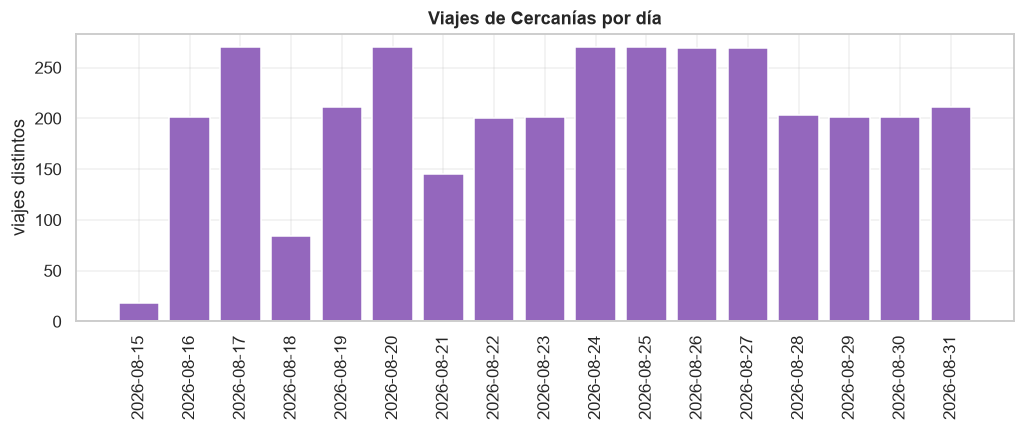

,dia,viajes,trenes,retraso_medio
0,2026-08-15,18,18,1.720
1,2026-08-16,201,201,1.280
2,2026-08-17,270,270,2.950
3,2026-08-18,84,84,3.740
4,2026-08-19,211,211,2.710
5,2026-08-20,270,270,3.630
6,2026-08-21,145,145,2.350
7,2026-08-22,200,200,0.720
8,2026-08-23,201,201,1.300
9,2026-08-24,270,270,1.180


In [13]:
serv = eu.sql(
    """
    SELECT date AS dia,
           count(DISTINCT tripId) AS viajes,
           count(DISTINCT codTren) AS trenes,
           avg(retraso_min) AS retraso_medio
    FROM {f} GROUP BY 1 ORDER BY 1
    """,
    f=FUENTE,
)
fig, ax = plt.subplots(figsize=(11, 3.4))
ax.bar(serv["dia"].astype(str), serv["viajes"], color=eu.PALETA[FUENTE])
ax.set_ylabel("viajes distintos")
ax.set_title("Viajes de Cercanías por día")
plt.xticks(rotation=90)
plt.show()
serv.round(2)

In [14]:
# porAvanc: ¿sirve de algo o es ruido con nombre?
eu.frecuencias(FUENTE, "porAvanc", top=10)

,valor,filas,pct,pct_acum
0,A,152882,33.504,33.504
1,E,133314,29.216,62.719
2,None,45829,10.043,72.763
3,30.0,2834,0.621,73.384
4,20.0,2799,0.613,73.997
5,25.0,2759,0.605,74.602
6,28.0,2658,0.582,75.184
7,26.0,2656,0.582,75.766
8,22.0,2648,0.580,76.347
9,35.0,2636,0.578,76.924


`porAvanc` **mezcla dos tipos de dato en la misma columna**: dos códigos de letra
que se llevan casi dos tercios de las filas, un 10 % de nulos y, después, una cola
larga de valores numéricos en forma de texto, cada uno con una fracción mínima.

Una columna así no se puede castear ni ordenar, y su significado no está
documentado. **No entra en las features**: entrar significaría inventarle una
semántica. Vale la pena, eso sí, no borrarla del corpus — si algún día aparece la
documentación de la fuente, el histórico ya estará capturado, y capturado no se
puede volver a estar.

## 7. Hallazgos

1. **El retraso publicado tiene masa en cero (cuatro de cada diez observaciones)
   y cola larga hasta las siete horas.** Confirma que el baseline de "retraso = 0"
   es un rival serio, que la mediana es 0 y por tanto inútil como métrica, y que
   la variante binaria `> 5 min` estará desbalanceada en torno a uno contra ocho.
   Se reporta precisión y exhaustividad, no exactitud.
2. **El retraso crece a lo largo del día**, de cero de madrugada a casi un 20 % de
   observaciones por encima de 5 min a última hora: es acumulativo dentro del
   viaje, no independiente entre observaciones. Refuerza la obligación del split
   temporal — un split aleatorio filtraría el futuro del mismo viaje y daría
   métricas infladas. Es lo primero que buscará el tribunal.
3. **Los retrasos negativos son mayoritariamente legítimos** (trenes adelantados
   unos minutos) salvo un puñado de valores imposibles de hasta veintiuna horas.
   Esos pocos son el artefacto del cruce de medianoche: exactamente el bug que
   `prepare.py` reproducirá al construir la etiqueta del bus si no se cuida el
   cambio de día, y con la misma frecuencia baja que lo hace invisible.
4. **El filtro de núcleo 40 está funcionando** (trampa 003), pero el núcleo es
   **regional**: de Utiel al norte de Castelló. Como covariable de un bus urbano
   solo tiene sentido agregado, no tren a tren.
5. **`porAvanc` mezcla letras y números en la misma columna** y no está
   documentada. Fuera de las features; dentro del corpus, por si algún día se
   documenta.
6. **La ausencia nocturna de filas no es un hueco de captura**: Cercanías no
   circula. Tratarla como dato perdido falsearía la disponibilidad de la fuente.